In [33]:
train_dir = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_1.0/FD-027/train'

In [34]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

from src.dataloader.dataloaders import MadisonDatasetLabeled

In [35]:
import matplotlib.pyplot as plt

In [36]:
train_dataset = MadisonDatasetLabeled(train_dir, augment=True)

Segmentation path: /home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_1.0/FD-027/train
Number of images: 11254
Number of masks: 11254
Number of fake images: 0


In [37]:
import cv2
import numpy as np

In [38]:
# Iterate over the dataset
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    image, mask, path = sample
    
    # Print the shape of the image and mask
    

    # if (mask.shape[0] != 1):
    #     mask_np = (mask * 255).byte().cpu().numpy()        # (4, H, W)
    #     mask_hwc = np.transpose(mask_np, (1, 2, 0))        # (H, W, 4)
    #     mask = cv2.cvtColor(np.asarray(mask_hwc).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    #     mask = np.array([mask])
    


Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: (250, 250, 4)
Mask shape: 

KeyboardInterrupt: 

In [ ]:
np.array([mask])

(1, 256, 256)

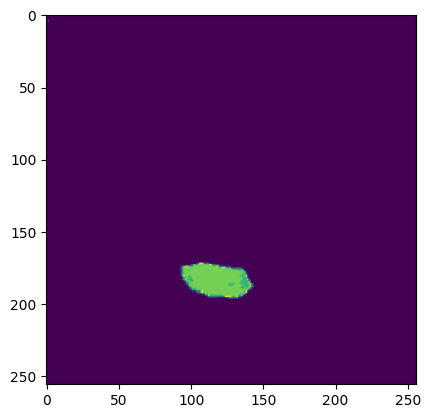

In [ ]:
plt.imshow(mask)

In [ ]:
mask_np = (mask * 255).byte().cpu().numpy()        # (4, H, W)
mask_hwc = np.transpose(mask_np, (1, 2, 0))        # (H, W, 4)

mask = cv2.cvtColor(np.asarray(mask_hwc).astype(np.uint8), cv2.COLOR_RGB2GRAY)

AttributeError: 'numpy.ndarray' object has no attribute 'byte'

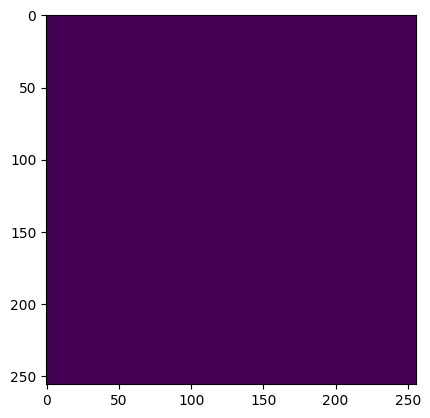

In [ ]:
plt.imshow(mask)

In [ ]:
FOLDER_PATH = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples'

import os
import glob
from torchvision import io
from skimage.metrics import structural_similarity as ssim


In [39]:
from tqdm import tqdm

In [58]:
synthetic_image_data = []

for folder in tqdm(os.listdir(FOLDER_PATH)):
    folder_path = os.path.join(FOLDER_PATH, folder, 'train')
    base_images = [file for file in os.listdir(folder_path) if 'mask' not in file and 'synthetic' not in file]
    for base_image in tqdm(base_images):
        original_image_path = os.path.join(folder_path, base_image)

        original_image = io.read_image(original_image_path)

        synthetic_images_of_base = [file for file in os.listdir(folder_path) if 'synthetic' in file and base_image.split('.')[0] in file]
        for synthetic_image_name in synthetic_images_of_base:
            synthetic_image_path = os.path.join(folder_path, synthetic_image_name)
            synthetic_image = io.read_image(synthetic_image_path)
            synthetic_image = synthetic_image[:3]


            # Resize to 256x256
            synthetic_image = np.transpose(synthetic_image, (1, 2, 0))
            synthetic_image = cv2.resize(np.asarray(synthetic_image), (256, 256), interpolation=cv2.INTER_LINEAR)
            synthetic_gray = cv2.cvtColor(np.asarray(synthetic_image), cv2.COLOR_RGB2GRAY)

            ssim_value = ssim(np.asarray(original_image[0]).astype(np.uint8), synthetic_gray)

            synthetic_image_data.append({
                'original_image_path': original_image_path,
                'synthetic_image_path': synthetic_image_path,
                'ssim_value': ssim_value
            })
        

100%|██████████| 5/5 [11:52<00:00, 142.49s/it]


In [59]:
import pandas as pd
synthetic_image_data = pd.DataFrame(synthetic_image_data)

In [62]:
synthetic_image_data.to_csv('synthetic_image_data.csv')

In [65]:
from pathlib import Path

In [66]:

synthetic_image_data['folder'] = synthetic_image_data['synthetic_image_path'] \
                 .apply(lambda p: Path(p).parent.parent.name)

In [68]:
synthetic_image_data['folder'].value_counts()

folder
FD-031    19212
FD-027    18788
FD-032    18572
FD-030    18400
FD-029    18252
Name: count, dtype: int64

In [72]:
synthetic_image_data[synthetic_image_data['ssim_value'] > 0.5]['folder'].value_counts()

folder
FD-031    9317
FD-027    8970
FD-029    8944
FD-030    8578
FD-032    7653
Name: count, dtype: int64

In [64]:
synthetic_image_data[synthetic_image_data['ssim_value'] > 0.5]

,original_image_path,synthetic_image_path,ssim_value
0,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.546084
3,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.528725
7,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.575990
13,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.603618
15,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.514116
...,...,...,...
93216,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.582763
93217,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.580904
93219,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.620969
93221,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.614282


In [ ]:
synthetic_image_data_hq = synthetic_image_data[synthetic_image_data['ssim_value'] > 0.5]

In [50]:
for file in synthetic_image_data['synthetic_image_path'].values:
    os.remove(file)

In [49]:
synthetic_image_data['synthetic_image_path'].values[0]

'/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-027-slice-71-image-synthetic-22_img.png'

In [89]:
synthetic_image_data = synthetic_image_data[[True if 'mask' not in file else False for file in synthetic_image_data['synthetic_image_path'].values]]

In [90]:
synthetic_image_data

,original_image_path,synthetic_image_path,ssim_value,folder
0,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.546084,FD-030
3,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.528725,FD-030
7,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.575990,FD-030
9,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.452907,FD-030
13,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.603618,FD-030
...,...,...,...,...
93216,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.582763,FD-031
93217,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.580904,FD-031
93219,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.620969,FD-031
93221,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.614282,FD-031


In [92]:
lq_files

,original_image_path,synthetic_image_path,ssim_value,folder
9,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.452907,FD-030
36,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.472382,FD-030
39,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.477522,FD-030
64,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.486744,FD-030
74,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.475739,FD-030
...,...,...,...,...
93037,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.477476,FD-031
93068,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.488083,FD-031
93125,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.495131,FD-031
93196,/home/miguel/GI/1.5 - Synthetic Data Generatio...,/home/miguel/GI/1.5 - Synthetic Data Generatio...,0.489129,FD-031


In [91]:
lq_files = synthetic_image_data[synthetic_image_data['ssim_value'] < 0.5]

In [96]:
for file in lq_files['synthetic_image_path'].values:
    try:
        os.remove(file)
        os.remove(file.replace('_img', '_mask'))
    except Exception as e:
        print(f"Error removing file {file}: {e}")
        continue
    # break

Error removing file /home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-032-slice-04-image-synthetic-48_img.png: [Errno 2] No such file or directory: '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-032-slice-04-image-synthetic-48_img.png'
Error removing file /home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-032-slice-04-image-synthetic-19_img.png: [Errno 2] No such file or directory: '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-032-slice-04-image-synthetic-19_img.png'
Error removing file /home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_a

In [94]:
file

'/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples/FD-030/train/FD-032-slice-04-image-synthetic-19_img.png'